In [2]:
import os
os.getcwd()

'/Users/zorakramer/Safety/Assignment 2'

In [3]:
#Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Create dataframe from csv file
exposure = pd.read_csv('Data for model.csv')
exposure.head()

,year,Annual,ClimateZone,Precip05in,Precip1in,Snow10in,Temp90,FC_Min,FC_Max,PrincArt,...,HseHldH,WalkComH,TransComH,DegreeH,NoVehH,WalkComPctH,TransComPctH,NonWhitePctH,DegreePctH,NoVehPctH
0,2014,1.008715e+05,3,160,55,0.0,4.0,4,7,1,...,3442.366473,166.738041,1018.284763,1099.640883,947.562614,0.044633,0.272576,0.226225,0.193205,0.275265
1,2014,1.160158e+06,3,160,55,0.0,4.0,3,3,2,...,3162.386495,158.532153,773.437362,1590.916415,508.269792,0.036902,0.180034,0.326323,0.264586,0.160723
2,2014,5.230030e+05,3,160,55,0.0,4.0,3,7,1,...,4858.992498,916.155792,1430.823715,2858.854956,805.819303,0.155156,0.242317,0.723288,0.373215,0.165841
3,2014,5.453961e+05,3,160,55,0.0,4.0,3,7,1,...,2755.337596,111.032411,383.858091,721.283123,147.926427,0.026330,0.091027,0.348611,0.119821,0.053687
4,2014,1.303617e+05,3,160,55,0.0,4.0,3,4,1,...,1338.560970,22.904996,44.223395,574.407818,65.102869,0.017433,0.033658,0.334453,0.208903,0.048636


In [17]:
exposure.columns

Index(['year', 'Annual', 'ClimateZone', 'Precip05in', 'Precip1in', 'Snow10in',
       'Temp90', 'FC_Min', 'FC_Max', 'PrincArt', 'MinorArt', 'Collector',
       'FC_Sum', 'Int4way', 'SchoolsH', 'SchoolsQ', 'SchoolsT', 'Signal',
       'MaxSlope', 'DistWater', 'AllTransitH', 'Jobs30H', 'CommutersH',
       'TripswkH', 'RoutesH', 'AllTransitQ', 'Jobs30Q', 'CommutersQ',
       'TripswkQ', 'RoutesQ', 'AllTransitT', 'Jobs30T', 'CommutersT',
       'TripswkT', 'RoutesT', 'EmpSF_H', 'EmpSF_Q', 'EmpSF_T', 'EmpH', 'EmpQ',
       'EmpT', 'StMetersH', 'StSegH', 'StMetersQ', 'StSegQ', 'StMetersT',
       'StSegT', 'PopT', 'HseHldT', 'WalkComT', 'TransComT', 'DegreeT',
       'NoVehT', 'WalkComPctT', 'TransComPctT', 'NonWhitePctT', 'DegreePctT',
       'NoVehPctT', 'PopQ', 'HseHldQ', 'WalkComQ', 'TransComQ', 'DegreeQ',
       'NoVehQ', 'WalkComPctQ', 'TransComPctQ', 'NonWhitePctQ', 'DegreePctQ',
       'NoVehPctQ', 'PopH', 'HseHldH', 'WalkComH', 'TransComH', 'DegreeH',
       'NoVehH', 'WalkComPctH'

In [6]:
exposure['Int4way'].unique()

array([1, 0])

In [92]:
df = exposure[['Annual', 'TransComQ', 'NoVehQ', 'StSegQ', 'WalkComQ', 'EmpQ', 'Temp90','SchoolsQ', 'MaxSlope']]
df.describe()

,Annual,TransComQ,NoVehQ,StSegQ,WalkComQ,EmpQ,Temp90,SchoolsQ,Snow10in,MaxSlope
count,1.301000e+03,1301.000000,1301.000000,1301.000000,1301.000000,1301.000000,1301.000000,1301.000000,1301.000000,1301.000000
mean,7.328024e+05,89.128605,150.089949,328.902383,63.172210,3320.786318,33.077402,0.503459,0.212452,0.023807
std,2.029549e+06,249.879180,480.775379,170.073112,173.530924,7466.730638,34.053391,0.827988,1.013796,0.024613
min,0.000000e+00,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.550104e+04,1.379328,7.939576,211.000000,2.132940,325.000000,4.000000,0.000000,0.000000,0.007500
50%,1.434238e+05,14.984720,31.139169,317.000000,13.007883,934.000000,43.200000,0.000000,0.000000,0.015300
75%,5.436381e+05,82.992258,101.034383,421.000000,48.224044,2431.000000,43.500000,1.000000,0.000000,0.030900
max,2.579122e+07,3993.335124,8128.710073,1118.000000,2819.907077,64782.000000,178.800000,5.000000,5.600000,0.203100


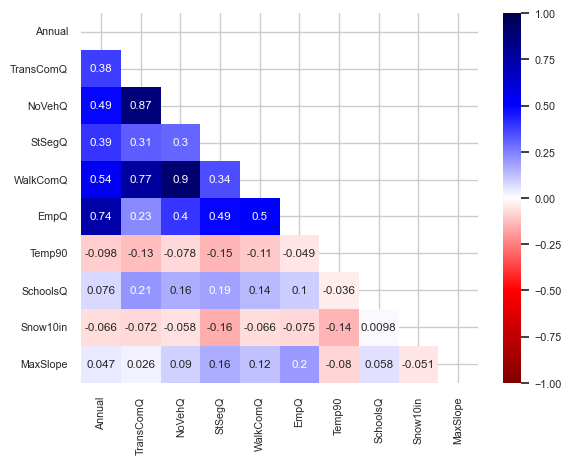

In [98]:
#Create heatmap of correlations among the variables
sns.set(context='notebook', style='whitegrid', font_scale=0.7)
upper = np.triu(df.corr())  # Here, we are looking at the upper triangle. Optionally, you can just look at the lower triangle. 
sns.heatmap(df.corr(), cmap="seismic_r", annot=True, vmin=-1, vmax=1, mask=upper);
plt.savefig('heatmap.png')

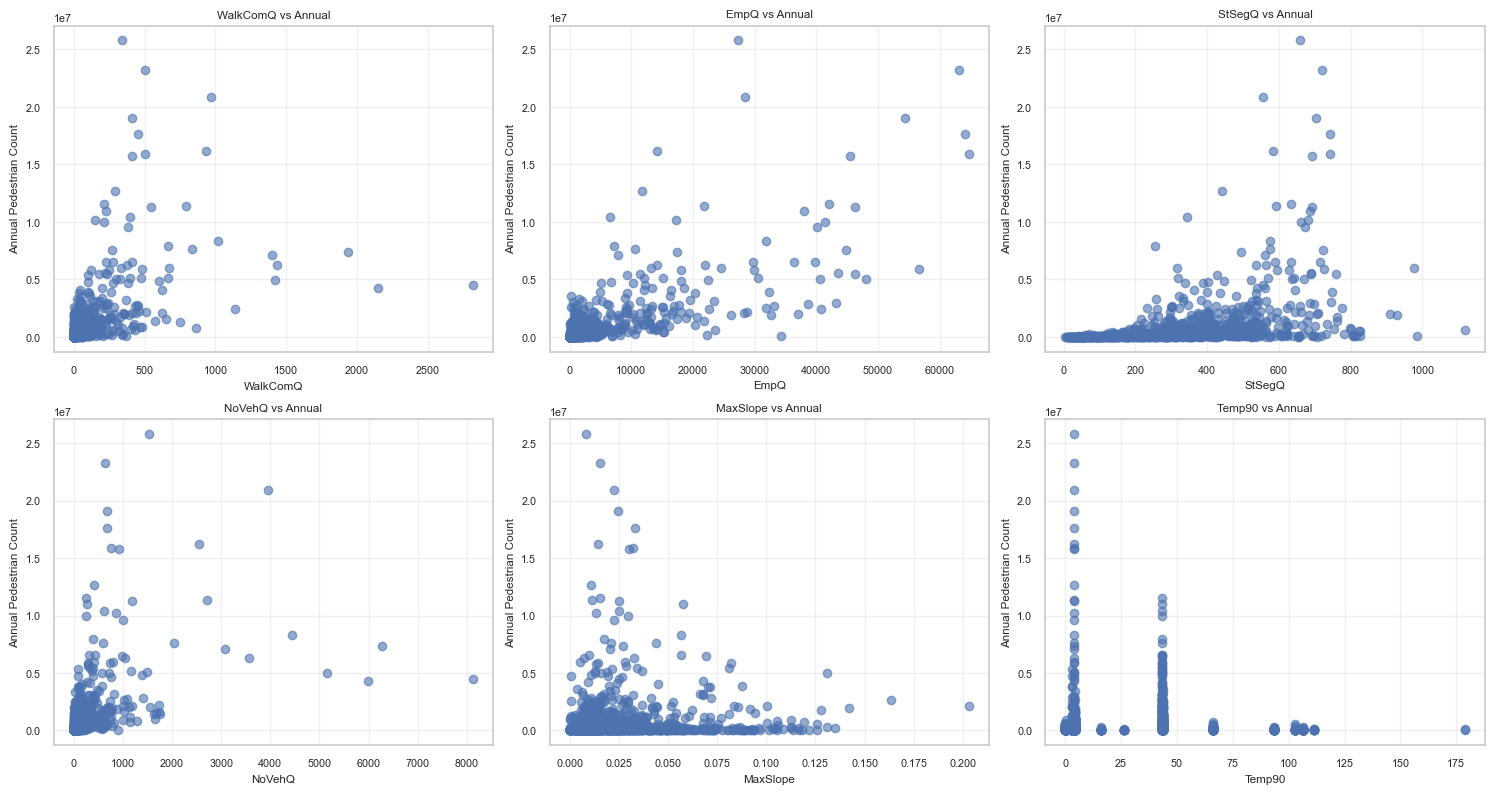

In [93]:
# Plot all dependent variables against one explanatory variable
dependent_vars = 'Annual'
explanatory_vars = ['WalkComQ', 'EmpQ', 'StSegQ', 'NoVehQ', 'MaxSlope', 'Temp90']

n_plots = len(dependent_vars)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

for i, exp_var in enumerate(explanatory_vars):
    axes[i].scatter(df[exp_var], df[dependent_vars], alpha=0.6)
    axes[i].set_ylabel('Annual Pedestrian Count')
    axes[i].set_xlabel(exp_var)
    axes[i].set_title(f'{exp_var} vs {dependent_vars}')
    axes[i].grid(True, alpha=0.3)

# Hide extra subplots
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [109]:
#Splitting into training & test data
X_train, X_test, y_train, y_test = train_test_split(df[ explanatory_vars], df['Annual'], test_size=0.33, random_state=42)

In [110]:
# Add a constant to the independent variables
X1 = sm.add_constant(X_train)

# Fit the linear regression model
lr_model = sm.OLS(y_train, X1).fit()

#print model summary
print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Annual   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.537
Method:                 Least Squares   F-statistic:                     169.1
Date:                Mon, 16 Feb 2026   Prob (F-statistic):          5.29e-142
Time:                        21:44:42   Log-Likelihood:                -13439.
No. Observations:                 871   AIC:                         2.689e+04
Df Residuals:                     864   BIC:                         2.692e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.861e+05   1.13e+05      2.531      0.0

In [111]:
# Add a constant to the independent variables
X = sm.add_constant(X_train)

# Fit the Poisson regression model
poisson_model = sm.GLM(y_train, X, family=sm.families.Poisson()).fit()

# Print the model summary
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Annual   No. Observations:                  871
Model:                            GLM   Df Residuals:                      864
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -3.0922e+08
Date:                Mon, 16 Feb 2026   Deviance:                   6.1842e+08
Time:                        21:48:03   Pearson chi2:                 9.84e+08
No. Iterations:                    11   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.0628      0.000   8.78e+04      0.0

In [112]:
# Add a constant to the independent variables
X = sm.add_constant(X_train)

# Fit the Negative Binomial model
model = sm.GLM(y_train, X, family=sm.families.NegativeBinomial(alpha = 1)).fit()

# Print the model summary
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Annual   No. Observations:                  871
Model:                            GLM   Df Residuals:                      864
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11849.
Date:                Mon, 16 Feb 2026   Deviance:                       2016.5
Time:                        21:59:59   Pearson chi2:                 2.34e+03
No. Iterations:                    40   Pseudo R-squ. (CS):             0.7900
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1151      0.093    119.910      0.0